# Data Exploration

### First exploration and context

In [ ]:
import pandas as pd

# Importing the dataset
df = pd.read_csv("creditcard.csv")

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


The dataset contains transactions made by credit cards in September 2013 by European cardholders.

V1-V28 are the principal components, they have been renamed for confidentiality issues.

In [ ]:
print(
    "There are {} non-fraudulent transactions ({:.3f}%) and {} fraudulent transactions ({:.3f}%)".format(
        pd.Series(df["Class"]).value_counts()[0],
        pd.Series(df["Class"]).value_counts()[0] / len(df["Class"]) * 100,
        pd.Series(df["Class"]).value_counts()[1],
        pd.Series(df["Class"]).value_counts()[1] / len(df["Class"]) * 100,
    )
)

There are 284315 non-fraudulent transactions (99.827%) and 492 fraudulent transactions (0.173%)


The dataset is very unbalanced.

## Correlation Matrix

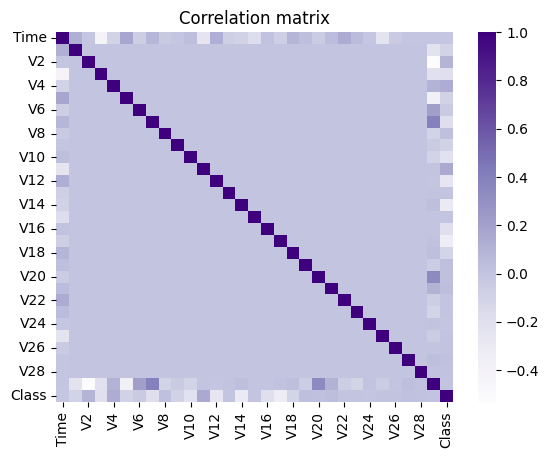

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the correlation matrix

plt.figure(1)
sns.heatmap(df.corr(), cmap="Purples")
plt.title("Correlation matrix")
plt.savefig("ressources/plots/correlation_matrix.png")
plt.show()

## Pairplots of the features

<Figure size 640x480 with 0 Axes>

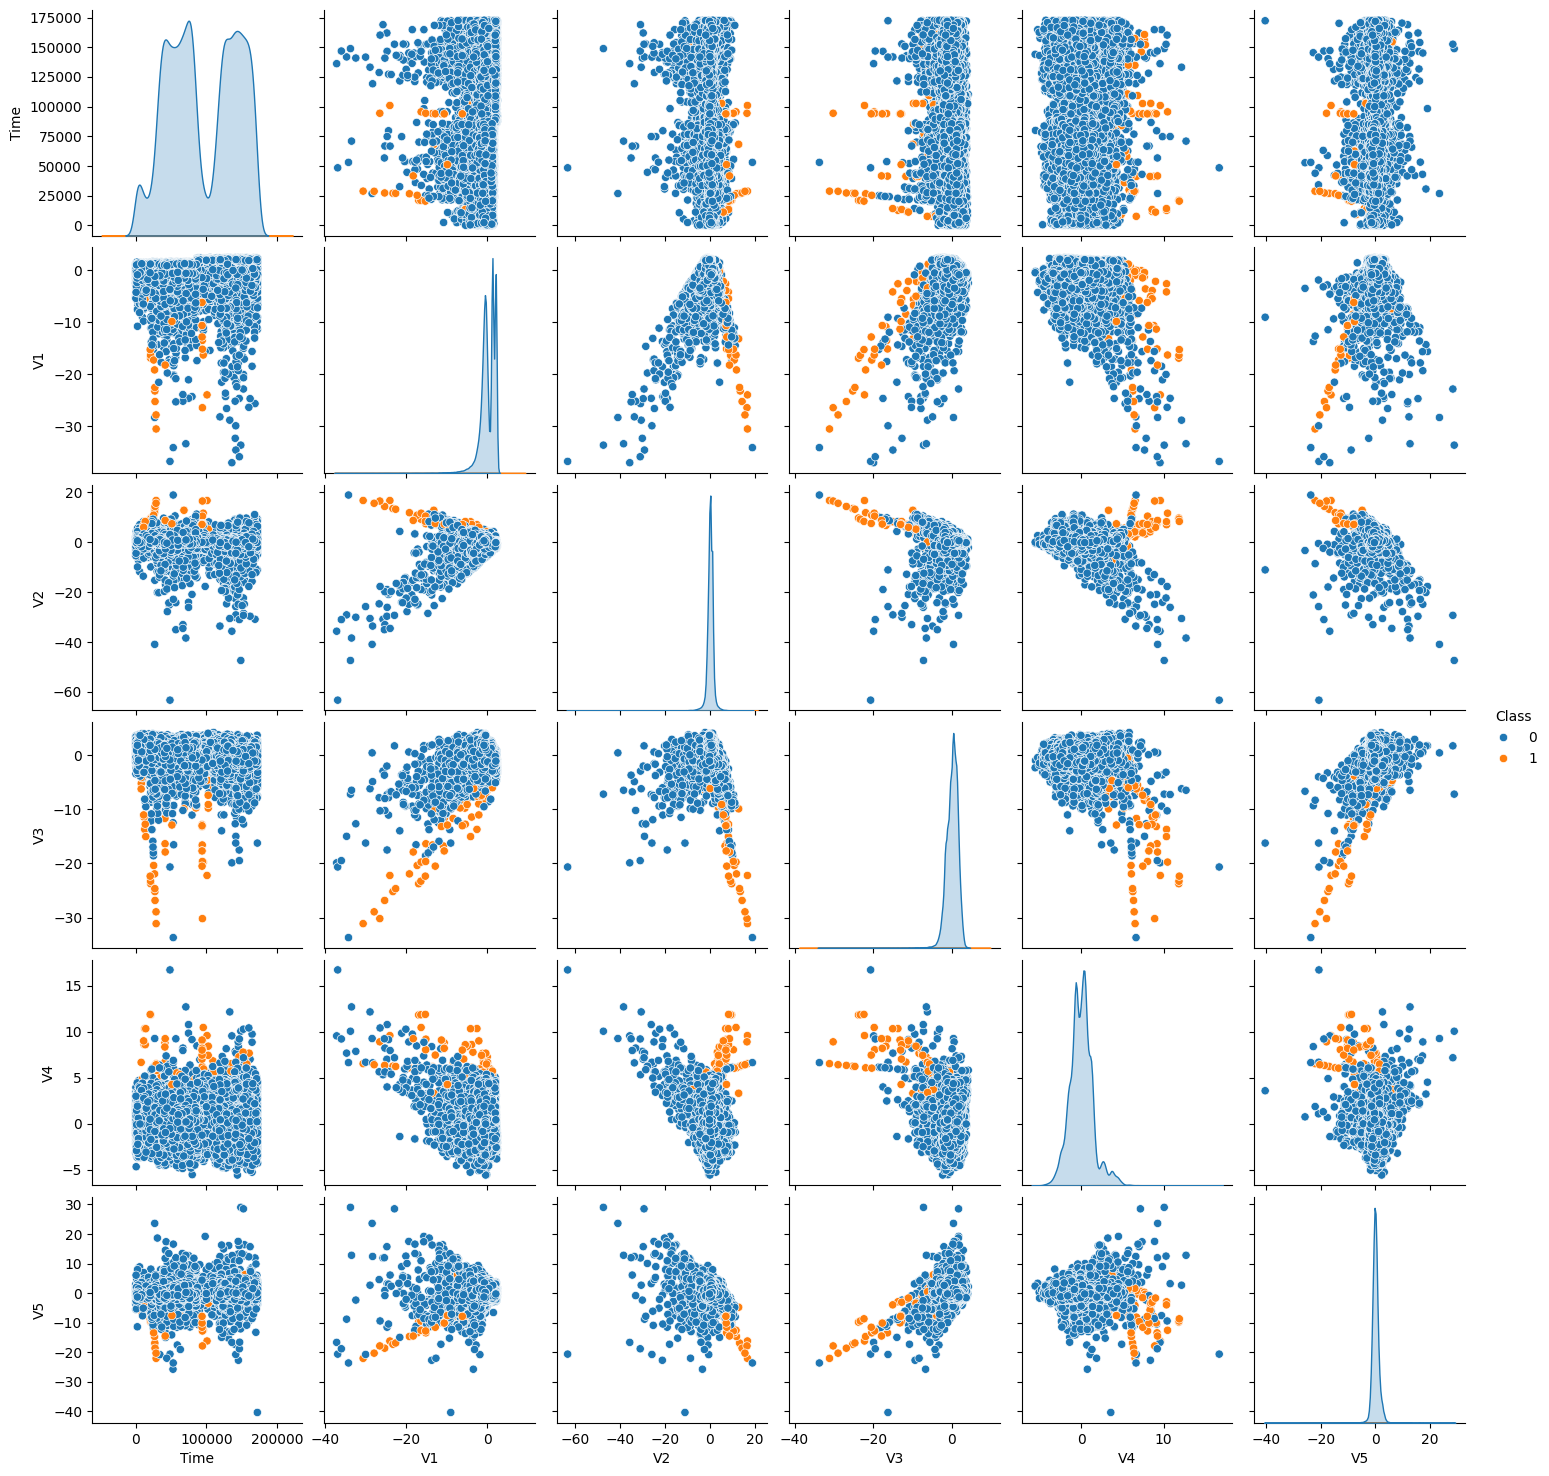

In [ ]:
plt.figure(2)
sns.pairplot(df.sample(80000), hue="Class", vars=["Time", "V1", "V2", "V3", "V4", "V5"])
plt.savefig("ressources/plots/pairplot1.png")

<Figure size 640x480 with 0 Axes>

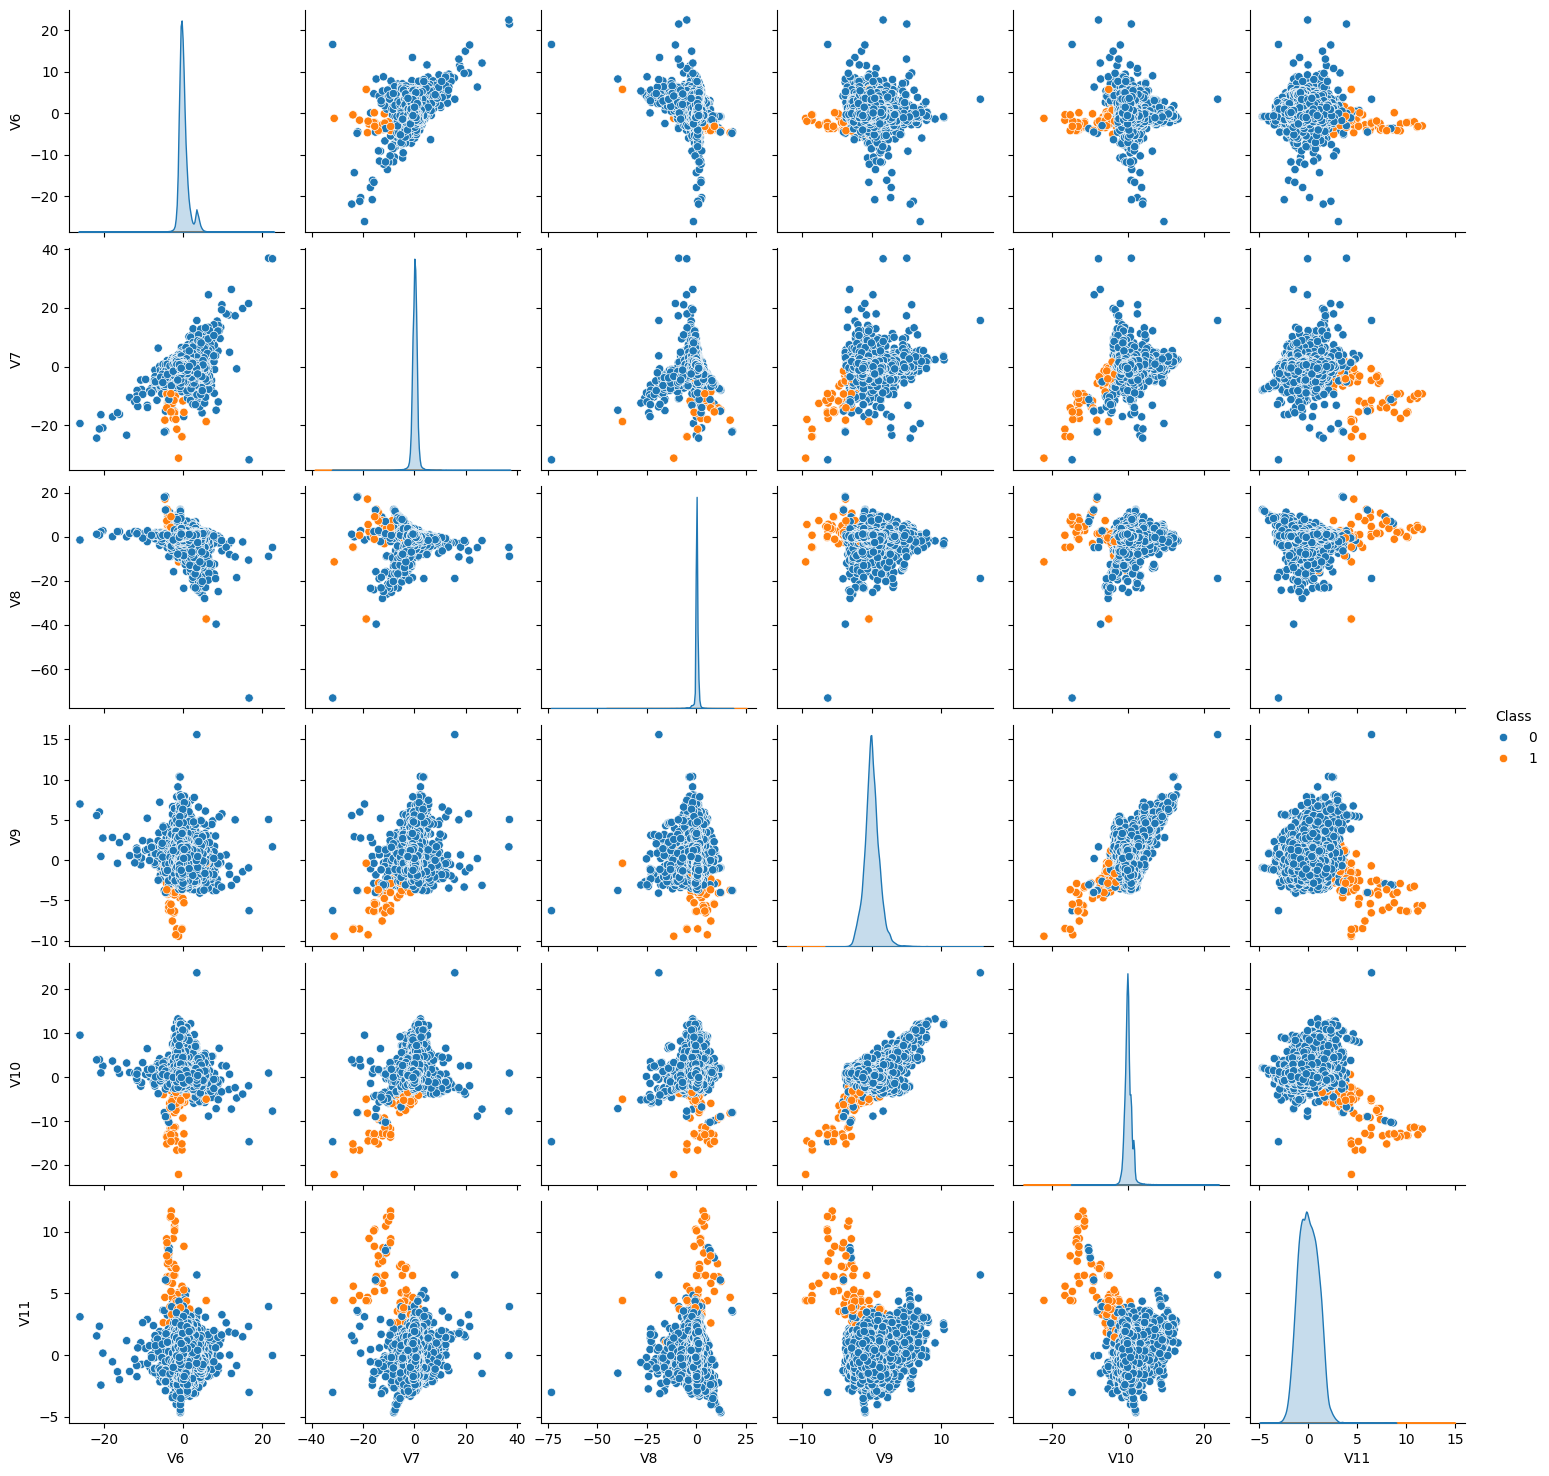

In [ ]:
plt.figure(3)
sns.pairplot(df.sample(80000), hue="Class", vars=["V6", "V7", "V8", "V9", "V10", "V11"])
plt.savefig("ressources/plots/pairplot2.png")

<Figure size 640x480 with 0 Axes>

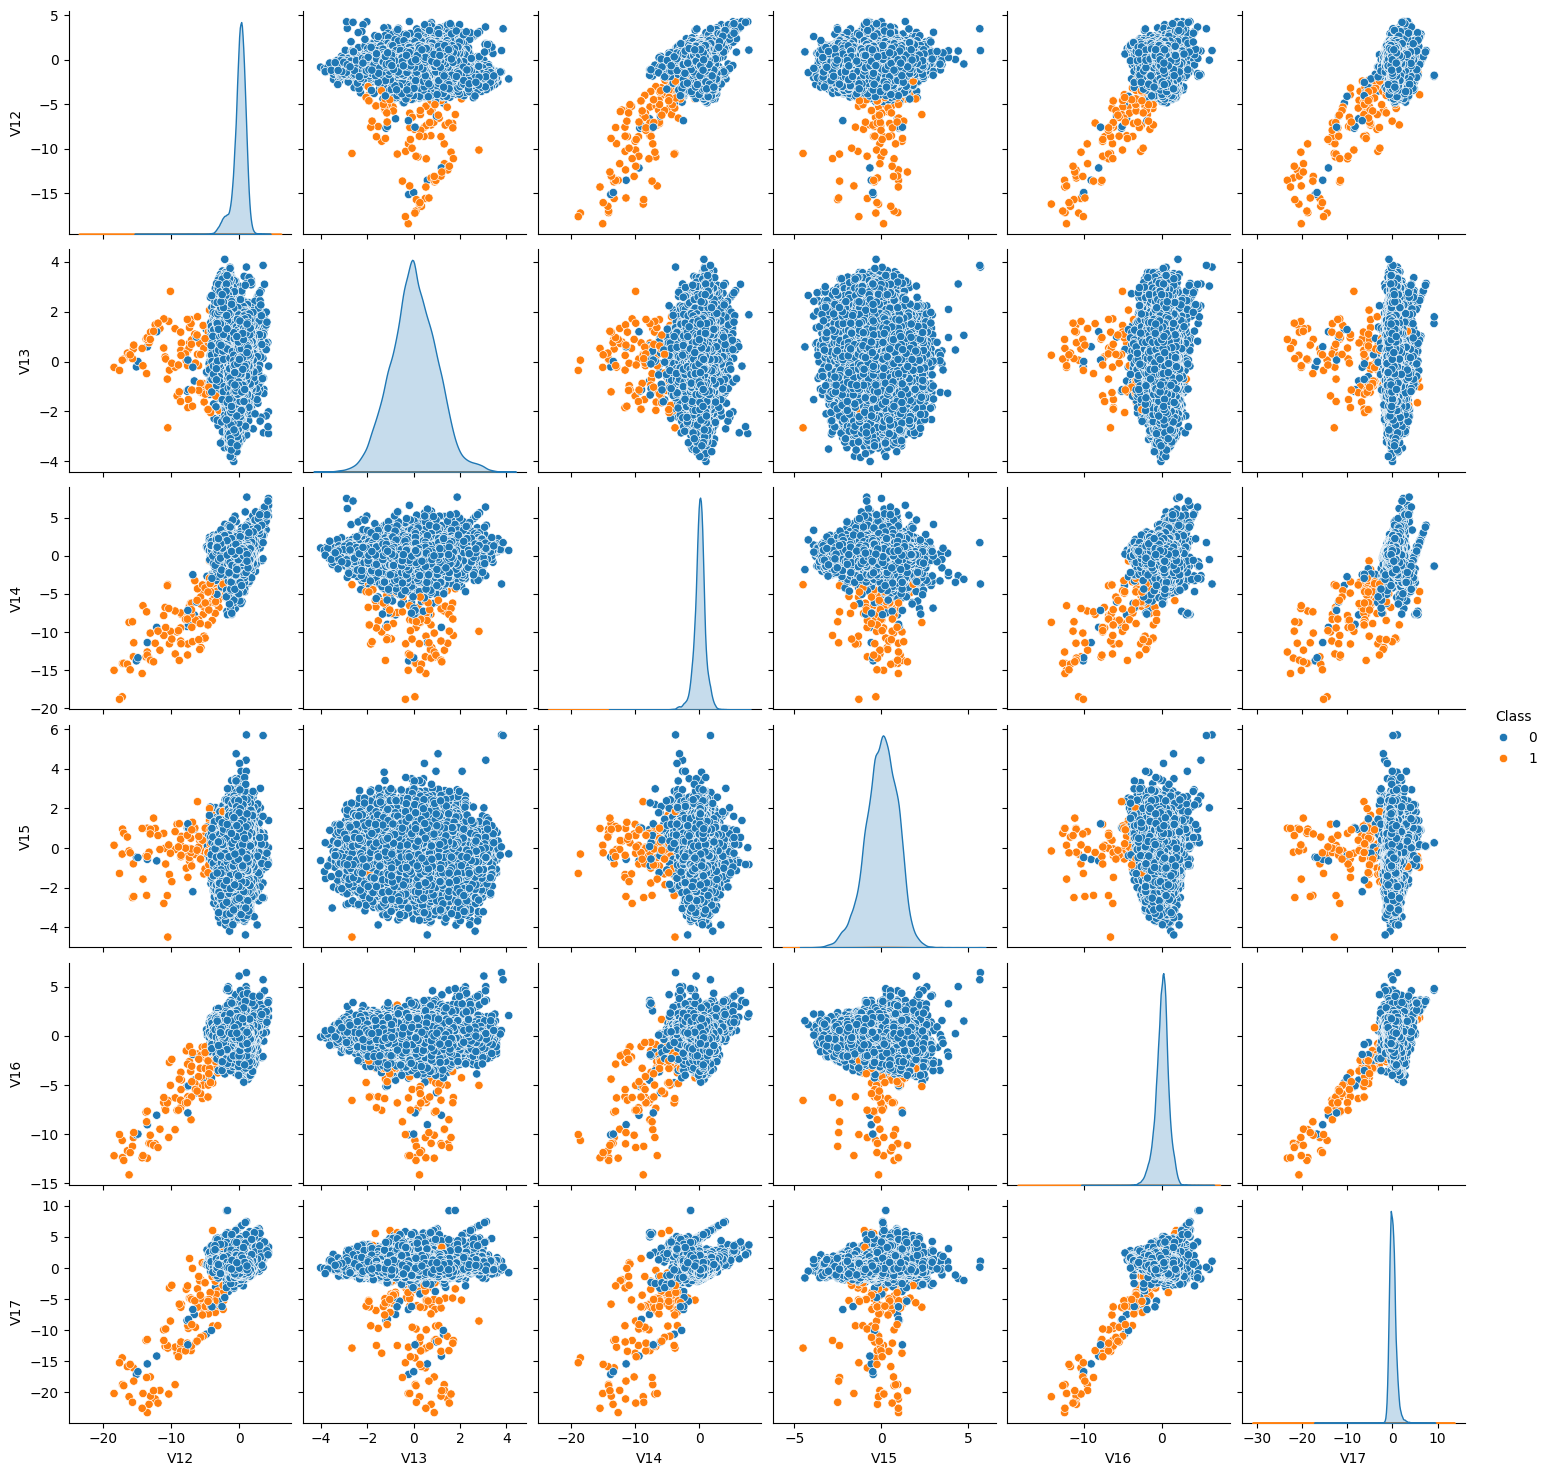

In [ ]:
plt.figure(4)
sns.pairplot(
    df.sample(80000), hue="Class", vars=["V12", "V13", "V14", "V15", "V16", "V17"]
)
plt.savefig("ressources/plots/pairplot3.png")

<Figure size 640x480 with 0 Axes>

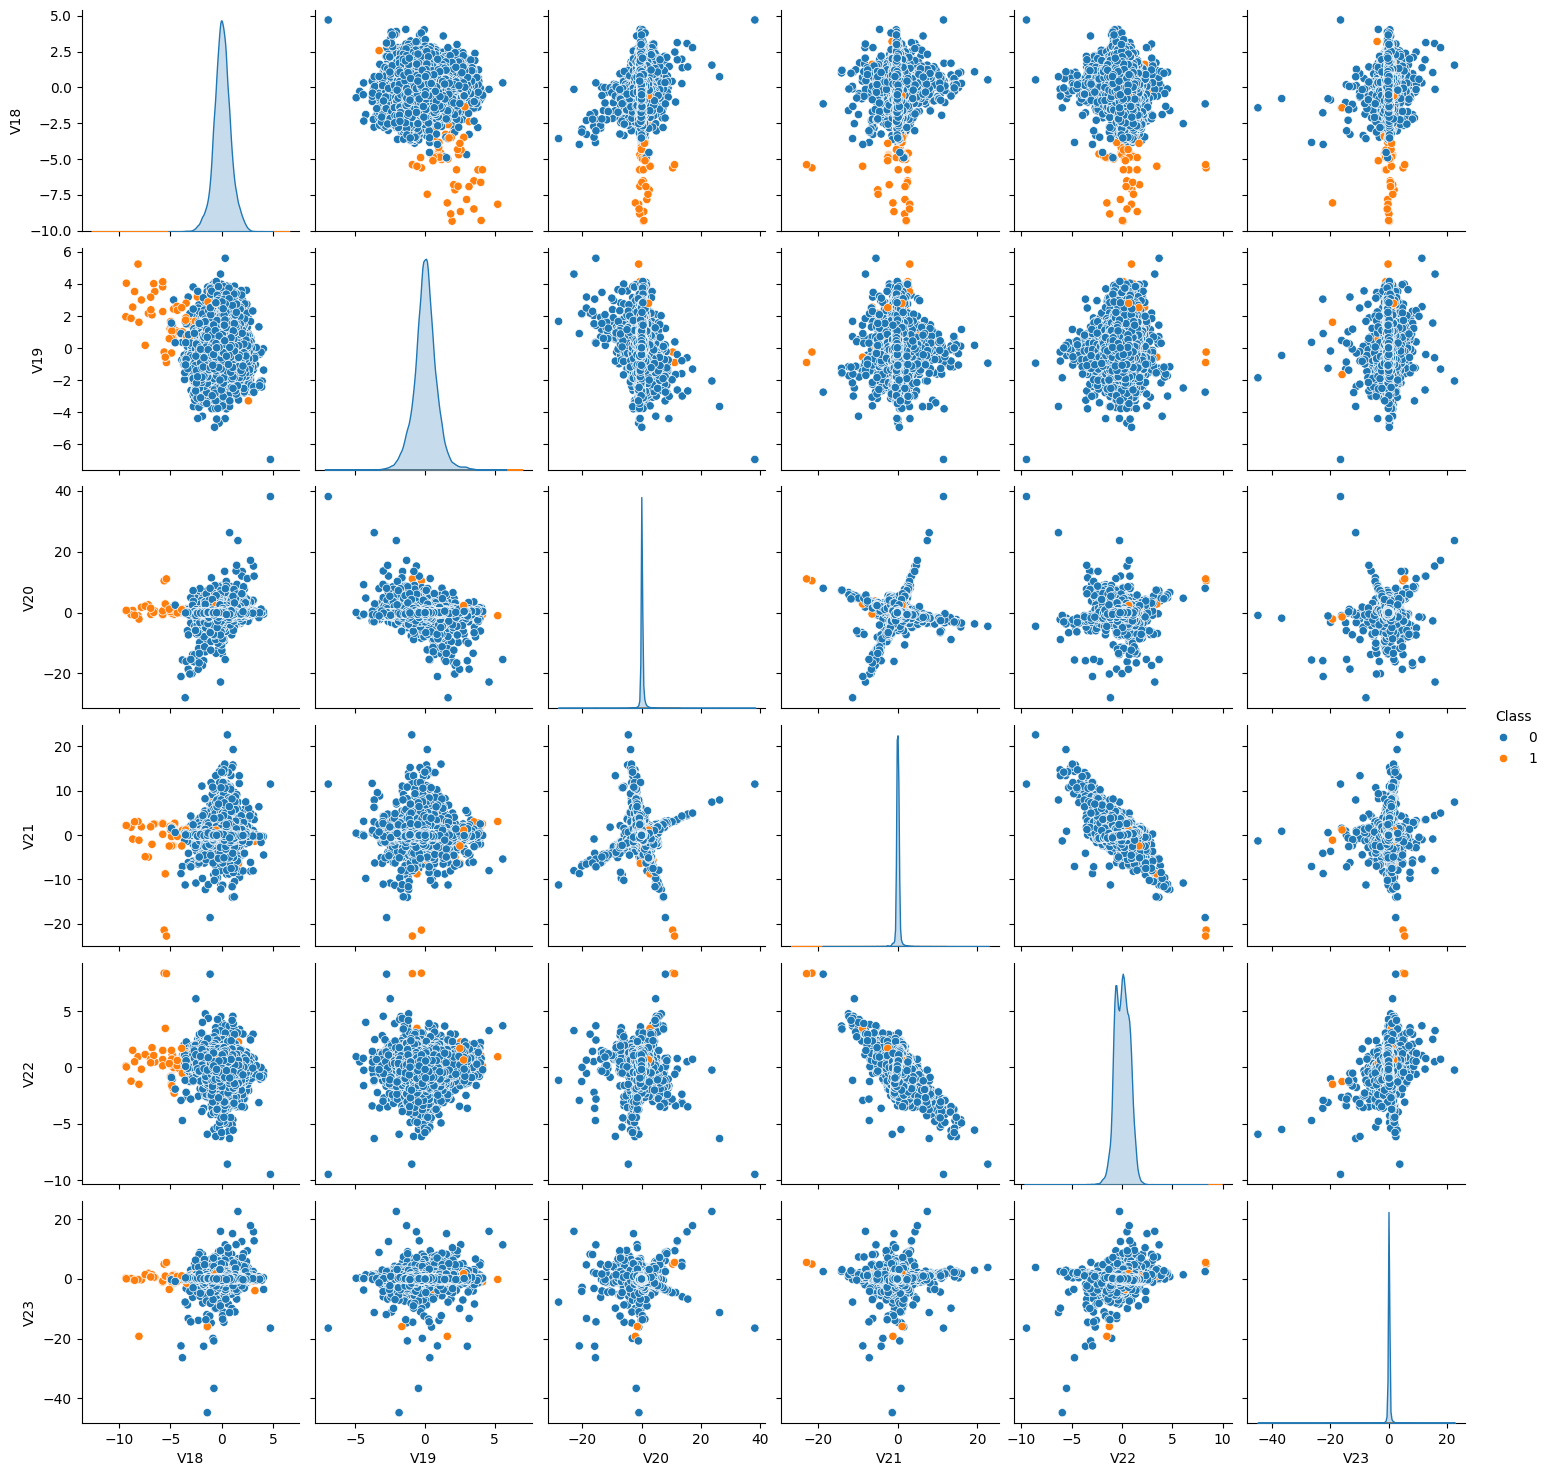

In [ ]:
plt.figure(5)
sns.pairplot(
    df.sample(80000), hue="Class", vars=["V18", "V19", "V20", "V21", "V22", "V23"]
)
plt.savefig("ressources/plots/pairplot4.png")

<Figure size 640x480 with 0 Axes>

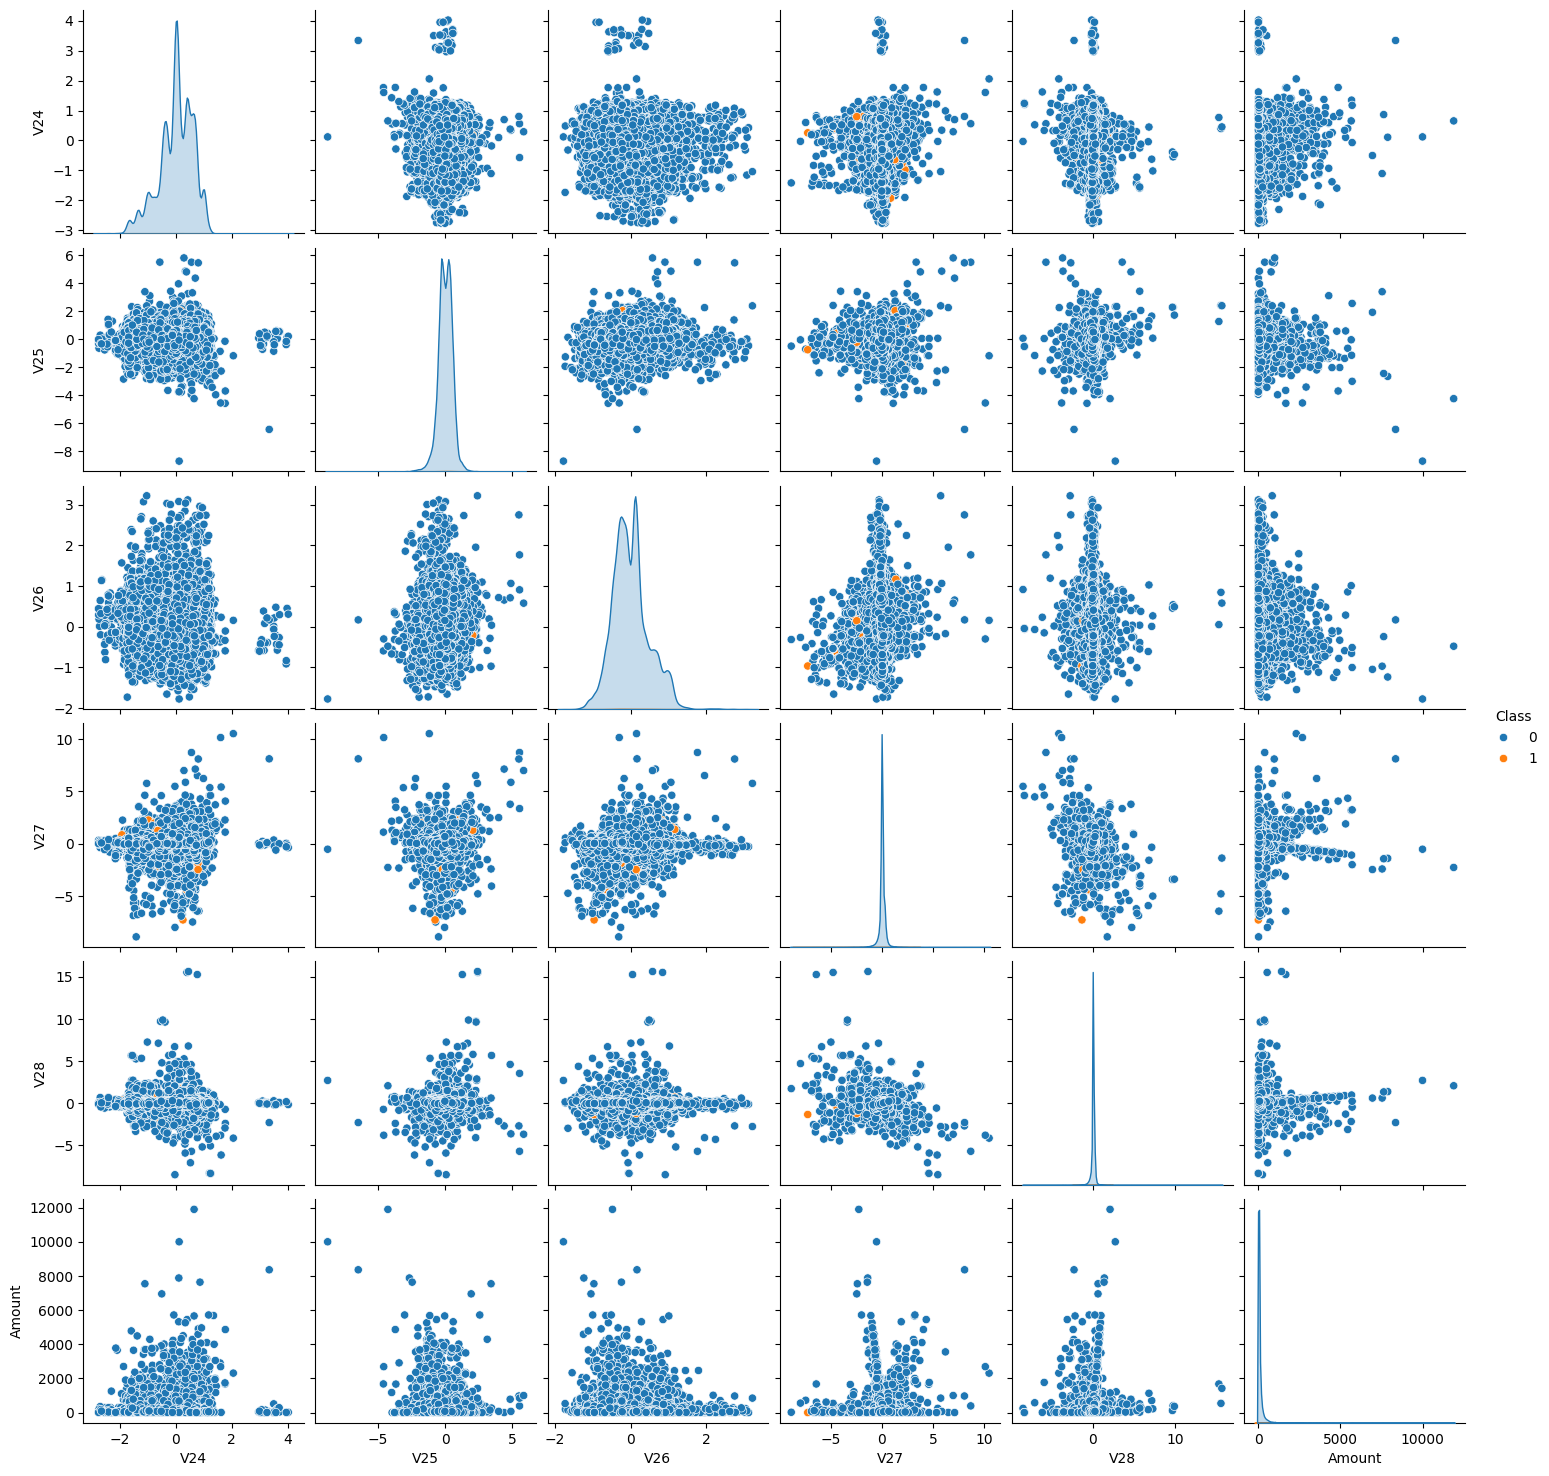

In [ ]:
plt.figure(6)
sns.pairplot(
    df.sample(80000), hue="Class", vars=["V24", "V25", "V26", "V27", "V28", "Amount"]
)
plt.savefig("ressources/plots/pairplot5.png")

Classes are visually separated for some features, the classification should work well

## Table of the missing values

In [ ]:
total_missing = df.isnull().sum().sort_values(ascending=False)
percent_missing = (df.isnull().sum() / df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat(
    [total_missing, percent_missing], axis=1, keys=["Total", "Percent"]
)
missing_data.head(10)

,Total,Percent
Time,0,0.0
V16,0,0.0
Amount,0,0.0
V28,0,0.0
V27,0,0.0
V26,0,0.0
V25,0,0.0
V24,0,0.0
V23,0,0.0
V22,0,0.0


No missing values